# **2.6 Probability**
**Simply put, machine learning is about making predictions.**<br><br>
Now let’s take a closer look at the first example: distinguishing between cats and dogs based on photos. This may sound simple, but it can be a daunting challenge for a machine. First, the difficulty of the problem may depend on the image resolution.
##### **(2.6.1F)**
![dogs and cats](../../images/picture2_6_1.png)
As shown in Figure [2.6.1](#261f), although humans can easily recognize cats and dogs at a resolution of 160×160 pixels, this becomes challenging at 40×40 pixels and is nearly impossible at 10×10 pixels.<br><br>
**Probability is a flexible language used to express our degree of certainty, and it can be effectively applied across a wide range of fields.**
## **2.6.1 Elementary Probability Theory**
In real life, when we receive actual dice from a factory, we need to check them for defects. The only way to inspect the dice is to roll them multiple times and record the results. For each die, we will observe a value from {1, ..., 6}. **For each value, a natural approach is to divide the number of times it appears by the total number of rolls, which gives us an estimate of the probability of that event. The law of large numbers tells us that as the number of rolls increases, this estimate will get closer and closer to the true underlying probability.** Let's give it a try with some code!

In [1]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

**In statistics, the process of drawing a sample from a probability distribution is called sampling. Broadly speaking, a distribution can be viewed as an assignment of probabilities to events**; we will provide a more formal definition later. **A distribution that assigns probabilities to a set of discrete choices is called a multinomial distribution**.<br><br>
To draw a sample—that is, to roll a die—we simply need to pass in a probability vector. The output is another vector of the same length: its value at index $i$ is the number of times $i$ appears in the sample.

In [2]:
fair_probs = torch.ones([6]) / 6
multinomial.Multinomial(1, fair_probs).sample()

tensor([0., 0., 0., 0., 1., 0.])

When estimating the fairness of a die, we want to generate multiple samples from the same distribution.

In [3]:
multinomial.Multinomial(10, fair_probs).sample()

tensor([1., 4., 0., 1., 1., 3.])

Then, after 1,000 tosses, we can count how many times each number was landed on. Specifically, we calculate the relative frequency as an estimate of the true probability.

In [4]:
# Store the result as a 32-bit floating-point number for division
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000 # Relative frequency as an estimate

tensor([0.1750, 0.1500, 0.1780, 0.1630, 0.1710, 0.1630])

We can also see how these probabilities converge to the true probability over time. Let’s conduct 500 sets of experiments, with 10 samples drawn in each set.

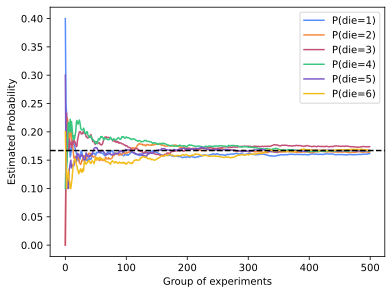

In [8]:
counts = multinomial.Multinomial(10, fair_probs).sample((500, ))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdim=True)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:,i].numpy(), label=('P(die=' + str(i + 1) + ')'))
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
d2l.plt.gca().set_xlabel('Group of experiments')
d2l.plt.gca().set_ylabel('Estimated Probability')
d2l.plt.legend();
d2l.plt.show()

### **Axioms of Probability Theory**
When considering the roll of a die, we refer to the set $S$ = {1, 2, 3, 4, 5, 6} as the sample space or outcome space, where each element is an outcome. **An event is a set of random outcomes within a given sample space.**<br><br>
Probability can be regarded as a function that maps sets to real numbers. In a given sample space $\mathbb{S}$, the probability of an event $A$, denoted by $P(A)$, satisfies the following properties:
* **For any event $A$, its probability is never negative; that is, $P(A) \geq 0$**;<br>
* **The probability of the entire sample space is 1, that is, $P(S) = 1$**;<br>
* **For any countable sequence $A_1, A_2,$ ... of mutually exclusive events (for all $i \neq j, A_i \cap A_j = \emptyset$), the probability that any event in the sequence occurs is equal to the sum of the probabilities of each event occurring, that is, $P(\bigcup_{i=1}^{\infty}A_i) = \sum_{i=1}^{\infty}P(A_{i})$.**<br>
### **Random Variable**
A random variable can take on almost any number of values, and it can take one value from a set of possibilities in a random experiment. To simplify the notation, on the one hand, we can represent $P(X)$ as a distribution on the random variable $X$: a distribution tells us the probability that $X$ takes on a certain value. On the other hand, we can simply denote the probability that a random variable takes the value $a$ as $P(a)$. Since an event in probability theory is a set of outcomes drawn from the sample space, we can specify the range of values that a random variable can take.
## **2.6.2 Handling Multiple Random Variables**
### **Joint Probability**
The first is called the joint probability $P(A = a, B = b)$. Given any values $a$ and $b$, the joint probability answers the question: What is the probability that both $A = a$ and $B = b$ are satisfied simultaneously? **Note that for any values of a and b, $P(A = a, B = b) \leq P(A = a)$. This is certain because for $A = a$ and $B = b$ to occur simultaneously, $A = a$ must occur, and $B = b$ must also occur (and vice versa). Therefore, the probability of $A = a$ and $B = b$ occurring simultaneously is no greater than the probability of either $A = a$ or $B = b$ occurring on its own.**
### **Conditional Probability**
The inequality in joint probability yields an interesting ratio: $0 \leq \frac{P(A = a, B = b)}{P(A = a)} \leq 1$. We call this ratio the conditional probability and denote it as $P(B = b | A = a)$: it is the probability that **$B = b$, given that $A = a$ has occurred**.
### **Bayes’ theorem**
By the multiplication rule, we obtain $P(A, B) = P(B | A)P(A)$. By symmetry, we obtain $P(A, B) = P(A | B)P(B)$. Assuming $P(B) > 0$, solving for one of the conditional variables, we obtain
##### (2.6.1)
$$P(A|B)=\frac{P(B | A)P(A)}{P(B)}$$<br><br>
Please note: $P(A, B)$ is a joint distribution, while $P(A|B)$ is a conditional distribution.
### **Marginalization**
To calculate the sum of event probabilities, we need the sum rule, which states that **the probability of $B$ is equivalent to calculating all possible choices for $A$ and aggregating the joint probabilities of all those choices**:
##### (2.6.2)
$$P(B)=\sum\limits_{A}P(A,B)$$<br><br>
This is also known as marginalization. The probability or distribution of the result of marginalization is called the marginal probability or marginal distribution.
### **Independence**
**If two random variables $A$ and $B$ are independent, it means that the occurrence of event $A$ is unrelated to the occurrence of event $B$. In this case, statisticians typically express this as $A⊥B$. According to Bayes’ theorem, we can immediately conclude that $P(A|B) = P(A)$. In all other cases, we say that A and B are dependent.**<br><br>
Since $P(A | B) = \frac{P(A, B)}{P(B)} = P(A)$ is equivalent to $P(A, B) = P(A)P(B)$, **two random variables are independent if and only if their joint distribution is the product of their individual distributions.** Similarly, given another random variable $C$, two random variables $A$ and $B$ are conditionally independent if and only if $P(A, B | C) = P(A | C)P(B | C)$. This is denoted as $A ⊥ B | C$.
## **2.6.4 Expectation and Variance**
The expectation (or mean) of a random variable X is defined as:
##### (2.6.9)
$$E[X]=\sum\limits_{x}xP(X=x)$$
When the input to the function $f(x)$ is a random variable drawn from distribution $P$, the expected value of $f(x)$ is:
##### (2.6.10)
$$E_{x~P}[f(x)]=\sum\limits_{x}f(x)P(x)$$
**Measures the bias of a random variable X relative to its expected value**. This can be quantified using variance:
##### (2.6.11)
$$Var[X]=E[(X-E[X])^{2}]=E[X^{2}]-E[X]^{2}$$
The square root of the variance is called the standard deviation.The variance of a function of a random variable measures the extent to which the function’s values deviate from the expected value of the function when different values x are sampled from the distribution of that random variable:
##### (2.6.12)
$$Var[f(x)]=E\left[(f(x)-E[f(x)])^{2}\right]$$
## **Summary**
* We can sample from a probability distribution.
* We can use joint distributions, conditional distributions, Bayes' theorem, marginalization, and the independence assumption to analyze multiple random variables.
* Expectation and variance provide practical measures for summarizing the key characteristics of a probability distribution.